In [1]:
from pathlib import Path
import pandas as pd

print("Python workspace ready")

Python workspace ready


In [2]:
# Update this folder if the dataset is stored elsewhere
dataset_folder = (
    Path.home()
    / "Downloads"
    / "CDU"
    / "PRT840 IT THESIS"
    / "CTU-SME-11_Experiment-VM-Microsoft-Windows7full-3_v1.0.0"
    / "CTU-SME-11"
    / "Experiment-VM-Microsoft-Windows7full-3"
)

log_files = sorted(
    dataset_folder.glob("*/zeek/conn.log.labeled")
)

if not log_files:
    raise FileNotFoundError(
        "No labelled connection logs were found. "
        "Update dataset_folder to the extracted CTU-SME-11 folder."
    )

print(f"Labelled connection logs found: {len(log_files)}")
for log_file in log_files:
    print(log_file.relative_to(dataset_folder))

Labelled connection logs found: 7
2023-02-20\zeek\conn.log.labeled
2023-02-21\zeek\conn.log.labeled
2023-02-22\zeek\conn.log.labeled
2023-02-23\zeek\conn.log.labeled
2023-02-24\zeek\conn.log.labeled
2023-02-25\zeek\conn.log.labeled
2023-02-26\zeek\conn.log.labeled


In [3]:
with open(log_files[0], "r", encoding="utf-8", errors="replace") as file:
    for line in file:
        print(line.rstrip())
        if line.startswith("#types"):
            break

#separator \x09
#set_separator	,
#empty_field	(empty)
#unset_field	-
#path	conn
#open	2023-03-22-10-01-20
#fields	ts	uid	id.orig_h	id.orig_p	id.resp_h	id.resp_p	proto	service	duration	orig_bytes	resp_bytes	conn_state	local_orig	local_resp	missed_bytes	history	orig_pkts	orig_ip_bytes	resp_pkts	resp_ip_bytes	tunnel_parents	label	detailedlabel
#types	time	string	addr	port	addr	port	enum	string	interval	count	count	string	bool	bool	count	string	count	count	count	count	set[string]	string	string


In [4]:
daily_results = []

for file in log_files:
    # Read the column names from the Zeek header
    with open(file, "r", encoding="utf-8", errors="replace") as opened_file:
        for line in opened_file:
            if line.startswith("#fields"):
                columns = line.rstrip().split("\t")[1:]
                break

    # Load only the two label columns
    labels = pd.read_csv(
        file,
        sep="\t",
        comment="#",
        header=None,
        names=columns,
        usecols=["label", "detailedlabel"],
        dtype=str
    )

    labels["label"] = labels["label"].str.strip().str.lower()
    counts = labels["label"].value_counts()

    benign = int(counts.get("benign", 0))
    malicious = int(counts.get("malicious", 0))
    unknown = int(counts.get("unknown", 0))

    daily_results.append({
        "date": file.parent.parent.name,
        "total": len(labels),
        "benign": benign,
        "malicious": malicious,
        "unknown": unknown,
        "other": len(labels) - benign - malicious - unknown
    })

    print(f"Finished {file.parent.parent.name}: {len(labels):,} records")

daily_summary = pd.DataFrame(daily_results)
daily_summary

Finished 2023-02-20: 7,941 records
Finished 2023-02-21: 54,432 records
Finished 2023-02-22: 40,935 records
Finished 2023-02-23: 10,939 records
Finished 2023-02-24: 13,319 records
Finished 2023-02-25: 5,902 records
Finished 2023-02-26: 7,604 records


,date,total,benign,malicious,unknown,other
0,2023-02-20,7941,7837,0,104,0
1,2023-02-21,54432,8768,44735,929,0
2,2023-02-22,40935,7187,33742,6,0
3,2023-02-23,10939,10478,459,2,0
4,2023-02-24,13319,13077,35,207,0
5,2023-02-25,5902,5846,0,56,0
6,2023-02-26,7604,7601,0,3,0


In [5]:
total_row = {
    "date": "TOTAL",
    "total": int(daily_summary["total"].sum()),
    "benign": int(daily_summary["benign"].sum()),
    "malicious": int(daily_summary["malicious"].sum()),
    "unknown": int(daily_summary["unknown"].sum()),
    "other": int(daily_summary["other"].sum())
}

daily_summary_final = pd.concat(
    [daily_summary, pd.DataFrame([total_row])],
    ignore_index=True
)

output_folder = Path("outputs")
output_folder.mkdir(exist_ok=True)

daily_summary_final.to_csv(
    output_folder / "daily_label_summary.csv",
    index=False
)

daily_summary_final

,date,total,benign,malicious,unknown,other
0,2023-02-20,7941,7837,0,104,0
1,2023-02-21,54432,8768,44735,929,0
2,2023-02-22,40935,7187,33742,6,0
3,2023-02-23,10939,10478,459,2,0
4,2023-02-24,13319,13077,35,207,0
5,2023-02-25,5902,5846,0,56,0
6,2023-02-26,7604,7601,0,3,0
7,TOTAL,141072,60794,78971,1307,0


In [6]:
detail_results = []

for file in log_files:
    with open(file, "r", encoding="utf-8", errors="replace") as opened_file:
        for line in opened_file:
            if line.startswith("#fields"):
                columns = line.rstrip().split("\t")[1:]
                break

    label_data = pd.read_csv(
        file,
        sep="\t",
        comment="#",
        header=None,
        names=columns,
        usecols=["label", "detailedlabel"],
        dtype=str,
        keep_default_na=False
    )

    label_data["label"] = label_data["label"].str.strip().str.lower()
    label_data["detailedlabel"] = label_data["detailedlabel"].str.strip()

    label_data.loc[
        label_data["detailedlabel"].isin(["", "-", "(empty)"]),
        "detailedlabel"
    ] = "Not specified"

    counts = (
        label_data.groupby(["label", "detailedlabel"])
        .size()
        .reset_index(name="records")
    )

    counts.insert(0, "date", file.parent.parent.name)
    detail_results.append(counts)

label_detail_summary = pd.concat(detail_results, ignore_index=True)

label_detail_summary.to_csv(
    output_folder / "daily_detailed_label_summary.csv",
    index=False
)

label_detail_summary

,date,label,detailedlabel,records
0,2023-02-20,benign,From_benign-To_benign,1360
1,2023-02-20,benign,From_benign-To_benign-1e100,1737
2,2023-02-20,benign,From_benign-To_benign-AWSGlobalAccelerator,2
3,2023-02-20,benign,From_benign-To_benign-Akamai,81
4,2023-02-20,benign,From_benign-To_benign-Amazon,59
...,...,...,...,...
106,2023-02-26,benign,From_benign-To_benign-Facebook,401
107,2023-02-26,benign,From_benign-To_benign-Facebook_CDN,1
108,2023-02-26,benign,From_benign-To_benign-Google,3
109,2023-02-26,benign,From_benign-To_benign-Multicast,1339


In [7]:
attack_summary = (
    label_detail_summary[
        label_detail_summary["label"] == "malicious"
    ]
    .sort_values(["date", "records"], ascending=[True, False])
    .reset_index(drop=True)
)

attack_summary.to_csv(
    output_folder / "daily_attack_summary.csv",
    index=False
)

attack_summary

,date,label,detailedlabel,records
0,2023-02-21,malicious,From_malicious-To_malicious-Malware_data_exfil...,44729
1,2023-02-21,malicious,From_malicious-To_malicious-Malware_C2-Ingress...,6
2,2023-02-22,malicious,From_malicious-To_malicious-Malware_data_exfil...,33739
3,2023-02-22,malicious,From_malicious-To_malicious-Malware_C2-Ingress...,3
4,2023-02-23,malicious,From_malicious-To_malicious-Malware_data_exfil...,442
5,2023-02-23,malicious,From_malicious-To_malicious-Malware_C2-Ingress...,11
6,2023-02-23,malicious,From_malicious-To_malicious-Human_attacks_data...,6
7,2023-02-24,malicious,From_malicious-To_malicious-Malware_data_exfil...,32
8,2023-02-24,malicious,From_malicious-To_malicious-Malware_C2-Ingress...,3


In [5]:
total_row = {
    "date": "TOTAL",
    "total": int(daily_summary["total"].sum()),
    "benign": int(daily_summary["benign"].sum()),
    "malicious": int(daily_summary["malicious"].sum()),
    "unknown": int(daily_summary["unknown"].sum()),
    "other": int(daily_summary["other"].sum())
}

daily_summary_final = pd.concat(
    [daily_summary, pd.DataFrame([total_row])],
    ignore_index=True
)

output_folder = Path("outputs")
output_folder.mkdir(exist_ok=True)

daily_summary_final.to_csv(
    output_folder / "daily_label_summary.csv",
    index=False
)

daily_summary_final

,date,total,benign,malicious,unknown,other
0,2023-02-20,7941,7837,0,104,0
1,2023-02-21,54432,8768,44735,929,0
2,2023-02-22,40935,7187,33742,6,0
3,2023-02-23,10939,10478,459,2,0
4,2023-02-24,13319,13077,35,207,0
5,2023-02-25,5902,5846,0,56,0
6,2023-02-26,7604,7601,0,3,0
7,TOTAL,141072,60794,78971,1307,0


In [8]:
for row in attack_summary.itertuples(index=False):
    print(f"{row.date} | {row.records:,} records | {row.detailedlabel}")
    

2023-02-21 | 44,729 records | From_malicious-To_malicious-Malware_data_exfiltration-RemcosRAT
2023-02-21 | 6 records | From_malicious-To_malicious-Malware_C2-Ingress_tool_access-RemcosRAT-HTTP
2023-02-22 | 33,739 records | From_malicious-To_malicious-Malware_data_exfiltration-RemcosRAT
2023-02-22 | 3 records | From_malicious-To_malicious-Malware_C2-Ingress_tool_access-RemcosRAT-HTTP
2023-02-23 | 442 records | From_malicious-To_malicious-Malware_data_exfiltration-RemcosRAT
2023-02-23 | 11 records | From_malicious-To_malicious-Malware_C2-Ingress_tool_access-RemcosRAT-HTTP
2023-02-23 | 6 records | From_malicious-To_malicious-Human_attacks_data_exfiltration-PyExfil-DNS
2023-02-24 | 32 records | From_malicious-To_malicious-Malware_data_exfiltration-RemcosRAT
2023-02-24 | 3 records | From_malicious-To_malicious-Malware_C2-Ingress_tool_access-RemcosRAT-HTTP


In [9]:
attack_family_data = attack_summary.copy()

attack_family_data["attack_family"] = attack_family_data["detailedlabel"].apply(
    lambda value:
        "RemcosRAT" if "RemcosRAT" in value
        else "PyExfil-DNS" if "PyExfil-DNS" in value
        else "Other"
)

attack_family_summary = (
    attack_family_data
    .groupby(["date", "attack_family"])["records"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

attack_family_summary["total_malicious"] = (
    attack_family_summary
    .drop(columns="date")
    .sum(axis=1)
)

attack_family_summary.to_csv(
    output_folder / "daily_attack_family_summary.csv",
    index=False
)

attack_family_summary

attack_family,date,PyExfil-DNS,RemcosRAT,total_malicious
0,2023-02-21,0,44735,44735
1,2023-02-22,0,33742,33742
2,2023-02-23,6,453,459
3,2023-02-24,0,35,35


In [10]:
def read_zeek_connection_log(file):
    with open(file, "r", encoding="utf-8", errors="replace") as opened_file:
        for line in opened_file:
            if line.startswith("#fields"):
                columns = line.rstrip().split("\t")[1:]
                break

    day_data = pd.read_csv(
        file,
        sep="\t",
        comment="#",
        header=None,
        names=columns,
        dtype=str,
        keep_default_na=False,
        low_memory=False
    )

    day_data.insert(0, "capture_date", file.parent.parent.name)
    return day_data


daily_frames = []

for file in log_files:
    day_data = read_zeek_connection_log(file)
    daily_frames.append(day_data)
    print(f"Loaded {file.parent.parent.name}: {len(day_data):,} records")

combined_data = pd.concat(daily_frames, ignore_index=True)
del daily_frames

print()
print("Combined records:", f"{len(combined_data):,}")
print("Combined columns:", len(combined_data.columns))
print()
print(combined_data.columns.tolist())

Loaded 2023-02-20: 7,941 records
Loaded 2023-02-21: 54,432 records
Loaded 2023-02-22: 40,935 records
Loaded 2023-02-23: 10,939 records
Loaded 2023-02-24: 13,319 records
Loaded 2023-02-25: 5,902 records
Loaded 2023-02-26: 7,604 records

Combined records: 141,072
Combined columns: 24

['capture_date', 'ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents', 'label', 'detailedlabel']


In [11]:
# Create a consistent version of the label for grouping
combined_data["label_clean"] = (
    combined_data["label"]
    .str.strip()
    .str.lower()
)

sample_parts = []

for (date, label), group in combined_data.groupby(
    ["capture_date", "label_clean"],
    sort=True
):
    if label == "malicious":
        # Sample each malicious subtype separately so rare attacks remain included
        for detailed_label, attack_group in group.groupby(
            "detailedlabel",
            sort=True
        ):
            sample_size = min(200, len(attack_group))
            sample_parts.append(
                attack_group.sample(n=sample_size, random_state=42)
            )
    else:
        sample_size = min(200, len(group))
        sample_parts.append(
            group.sample(n=sample_size, random_state=42)
        )

analysis_sample = (
    pd.concat(sample_parts)
    .sort_values(["capture_date", "label_clean"])
    .reset_index(drop=True)
)

analysis_sample.to_csv(
    output_folder / "representative_analysis_sample.csv",
    index=False
)

sample_distribution = pd.crosstab(
    analysis_sample["capture_date"],
    analysis_sample["label_clean"]
)

print("Sample records:", f"{len(analysis_sample):,}")
sample_distribution

Sample records: 2,632


label_clean,benign,malicious,unknown
capture_date,,,
2023-02-20,200,0,104
2023-02-21,200,206,200
2023-02-22,200,203,6
2023-02-23,200,217,2
2023-02-24,200,35,200
2023-02-25,200,0,56
2023-02-26,200,0,3


In [12]:
# Read the original Zeek field types
zeek_fields = None
zeek_types = None

with open(log_files[0], "r", encoding="utf-8", errors="replace") as file:
    for line in file:
        if line.startswith("#fields"):
            zeek_fields = line.rstrip().split("\t")[1:]
        elif line.startswith("#types"):
            zeek_types = line.rstrip().split("\t")[1:]
            break

type_lookup = dict(zip(zeek_fields, zeek_types))
type_lookup["capture_date"] = "derived date"
type_lookup["label_clean"] = "derived target"

# Audit every column in the analysis sample
missing_markers = ["", "-", "(empty)"]
audit_results = []

for column in analysis_sample.columns:
    values = analysis_sample[column].astype(str).str.strip()
    missing = values.isin(missing_markers)
    non_missing = values[~missing]

    audit_results.append({
        "column": column,
        "type": type_lookup.get(column, "derived"),
        "missing": int(missing.sum()),
        "missing_percent": round(missing.mean() * 100, 2),
        "unique_non_missing": int(non_missing.nunique())
    })

feature_audit = pd.DataFrame(audit_results)

feature_audit.to_csv(
    output_folder / "feature_audit.csv",
    index=False
)

feature_audit

,column,type,missing,missing_percent,unique_non_missing
0,capture_date,derived date,0,0.00,7
1,ts,time,0,0.00,2632
2,uid,string,0,0.00,2632
3,id.orig_h,addr,0,0.00,7
4,id.orig_p,port,0,0.00,1946
5,id.resp_h,addr,0,0.00,204
6,id.resp_p,port,0,0.00,527
7,proto,enum,0,0.00,3
8,service,string,2041,77.55,13
9,duration,interval,333,12.65,2017


In [13]:
def create_feature_audit(data):
    results = []

    for column in data.columns:
        values = data[column].astype(str).str.strip()
        missing = values.isin(["", "-", "(empty)"])
        non_missing = values[~missing]

        results.append({
            "column": column,
            "type": type_lookup.get(column, "derived"),
            "missing": int(missing.sum()),
            "missing_percent": round(missing.mean() * 100, 2),
            "unique_non_missing": int(non_missing.nunique())
        })

    return pd.DataFrame(results)


full_feature_audit = create_feature_audit(combined_data)

full_feature_audit.to_csv(
    output_folder / "full_feature_audit.csv",
    index=False
)

full_feature_audit

,column,type,missing,missing_percent,unique_non_missing
0,capture_date,derived date,0,0.00,7
1,ts,time,0,0.00,141012
2,uid,string,0,0.00,141072
3,id.orig_h,addr,0,0.00,13
4,id.orig_p,port,0,0.00,24525
5,id.resp_h,addr,0,0.00,738
6,id.resp_p,port,0,0.00,4235
7,proto,enum,0,0.00,3
8,service,string,127587,90.44,16
9,duration,interval,10466,7.42,48105


In [14]:
columns_to_check = [
    "service",
    "duration",
    "orig_bytes",
    "resp_bytes",
    "history"
]

missingness_results = []

for label, group in combined_data.groupby("label_clean"):
    result = {
        "label": label,
        "records": len(group)
    }

    for column in columns_to_check:
        missing = (
            group[column]
            .astype(str)
            .str.strip()
            .isin(["", "-", "(empty)"])
        )

        result[f"{column}_missing_percent"] = round(
            missing.mean() * 100,
            2
        )

    missingness_results.append(result)

missingness_by_label = pd.DataFrame(missingness_results)

missingness_by_label.to_csv(
    output_folder / "missingness_by_label.csv",
    index=False
)

missingness_by_label

,label,records,service_missing_percent,duration_missing_percent,orig_bytes_missing_percent,resp_bytes_missing_percent,history_missing_percent
0,benign,60794,79.01,16.86,16.86,16.86,7.4
1,malicious,78971,99.94,0.26,0.26,0.26,0.0
2,unknown,1307,48.13,0.77,0.77,0.77,0.0


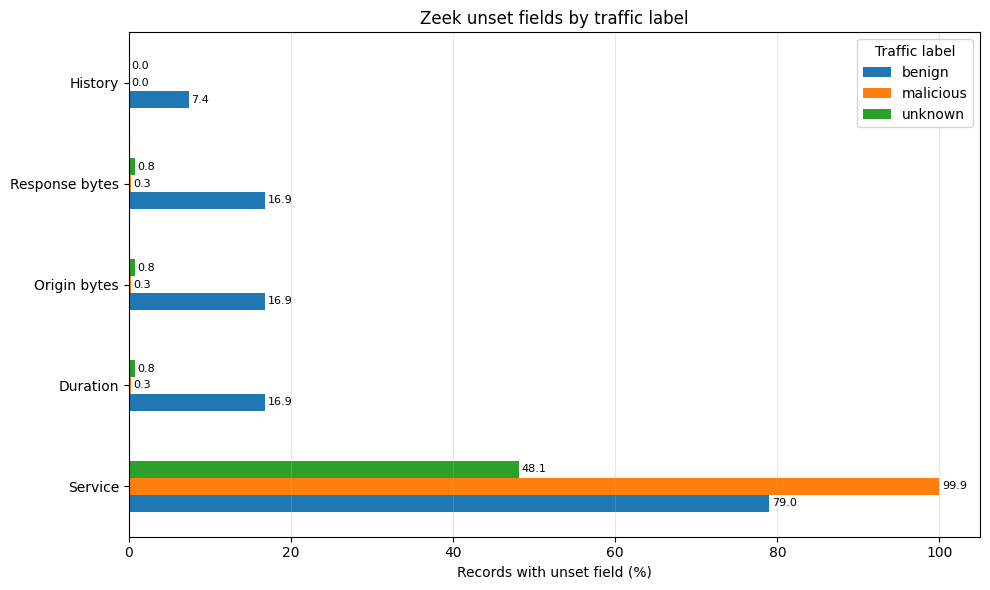

Saved figure: missingness_by_label.png


In [15]:
import matplotlib.pyplot as plt

plot_data = (
    missingness_by_label
    .set_index("label")
    .drop(columns="records")
    .transpose()
)

plot_data.index = [
    "Service",
    "Duration",
    "Origin bytes",
    "Response bytes",
    "History"
]

ax = plot_data.plot(
    kind="barh",
    figsize=(10, 6)
)

ax.set_title("Zeek unset fields by traffic label")
ax.set_xlabel("Records with unset field (%)")
ax.set_ylabel("")
ax.set_xlim(0, 105)
ax.legend(title="Traffic label")
ax.grid(axis="x", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=2,
        fontsize=8
    )

plt.tight_layout()

chart_path = output_folder / "missingness_by_label.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", chart_path.name)

In [16]:
zeek_file_names = sorted({
    file.name
    for day_folder in dataset_folder.iterdir()
    if day_folder.is_dir()
    for file in (day_folder / "zeek").glob("*")
    if file.is_file()
})

print("Additional Zeek files found:")
for name in zeek_file_names:
    print(name)

Additional Zeek files found:
capture_loss.log
conn.log.labeled
dce_rpc.log.labeled
dhcp.log.labeled
dns.log.labeled
dpd.log.labeled
files.log.labeled
http.log.labeled
kerberos.log.labeled
loaded_scripts.log
notice.log.labeled
ntlm.log.labeled
ntp.log.labeled
ocsp.log.labeled
packet_filter.log
reporter.log
smb_files.log.labeled
smb_mapping.log.labeled
ssl.log.labeled
stats.log
weird.log.labeled
x509.log.labeled


In [17]:
cti_candidate_logs = [
    "dns.log.labeled",
    "http.log.labeled",
    "ssl.log.labeled",
    "x509.log.labeled",
    "files.log.labeled",
    "dce_rpc.log.labeled",
    "smb_mapping.log.labeled",
    "ntlm.log.labeled"
]

for log_name in cti_candidate_logs:
    log_paths = sorted(dataset_folder.glob(f"*/zeek/{log_name}"))

    print(f"\n{log_name}")

    if not log_paths:
        print("Not found")
        continue

    with log_paths[0].open(
        "r", encoding="utf-8", errors="replace"
    ) as log_file:
        for line in log_file:
            if line.startswith("#fields"):
                fields = line.rstrip().split("\t")[1:]
                print(", ".join(fields))
                break


dns.log.labeled
ts, uid, id.orig_h, id.orig_p, id.resp_h, id.resp_p, proto, trans_id, rtt, query, qclass, qclass_name, qtype, qtype_name, rcode, rcode_name, AA, TC, RD, RA, Z, answers, TTLs, rejected, label, detailedlabel

http.log.labeled
ts, uid, id.orig_h, id.orig_p, id.resp_h, id.resp_p, trans_depth, method, host, uri, referrer, version, user_agent, origin, request_body_len, response_body_len, status_code, status_msg, info_code, info_msg, tags, username, password, proxied, orig_fuids, orig_filenames, orig_mime_types, resp_fuids, resp_filenames, resp_mime_types, label, detailedlabel

ssl.log.labeled
ts, uid, id.orig_h, id.orig_p, id.resp_h, id.resp_p, version, cipher, curve, server_name, resumed, last_alert, next_protocol, established, ssl_history, cert_chain_fps, client_cert_chain_fps, sni_matches_cert, validation_status, label, detailedlabel

x509.log.labeled
ts, fingerprint, certificate.version, certificate.serial, certificate.subject, certificate.issuer, certificate.not_valid_b

In [18]:
file_log_paths = sorted(
    dataset_folder.glob("*/zeek/files.log.labeled")
)

hash_rows = []

for log_path in file_log_paths:
    with log_path.open(
        "r", encoding="utf-8", errors="replace"
    ) as log_file:
        for line in log_file:
            if line.startswith("#fields"):
                fields = line.rstrip().split("\t")[1:]
                break

    file_data = pd.read_csv(
        log_path,
        sep="\t",
        comment="#",
        names=fields,
        dtype=str,
        na_values=["-", "(empty)"],
        low_memory=False
    )

    hash_rows.append({
        "date": log_path.parents[1].name,
        "file_records": len(file_data),
        "filenames_present": int(file_data["filename"].notna().sum()),
        "md5_present": int(file_data["md5"].notna().sum()),
        "sha1_present": int(file_data["sha1"].notna().sum()),
        "sha256_present": int(file_data["sha256"].notna().sum())
    })

hash_availability = pd.DataFrame(hash_rows)
hash_availability

,date,file_records,filenames_present,md5_present,sha1_present,sha256_present
0,2023-02-20,255,0,239,239,0
1,2023-02-21,253,0,247,247,0
2,2023-02-22,29,0,28,28,0
3,2023-02-23,138,0,132,132,0
4,2023-02-24,134,0,132,132,0
5,2023-02-25,16,0,16,16,0
6,2023-02-26,132,0,117,117,0


In [19]:
all_file_tables = []

for log_path in file_log_paths:
    with log_path.open(
        "r", encoding="utf-8", errors="replace"
    ) as log_file:
        for line in log_file:
            if line.startswith("#fields"):
                fields = line.rstrip().split("\t")[1:]
                break

    day_files = pd.read_csv(
        log_path,
        sep="\t",
        comment="#",
        names=fields,
        dtype=str,
        na_values=["-", "(empty)"],
        low_memory=False
    )

    day_files["capture_date"] = log_path.parents[1].name
    all_file_tables.append(day_files)

all_file_data = pd.concat(
    all_file_tables,
    ignore_index=True
)

md5_valid = all_file_data["md5"].str.fullmatch(
    r"[0-9A-Fa-f]{32}", na=False
)

sha1_valid = all_file_data["sha1"].str.fullmatch(
    r"[0-9A-Fa-f]{40}", na=False
)

hash_linkage_check = pd.DataFrame({
    "measure": [
        "All file records",
        "Records containing a hash",
        "Valid MD5 values",
        "Unique MD5 hashes",
        "Valid SHA1 values",
        "Unique SHA1 hashes",
        "Records with connection UID"
    ],
    "value": [
        len(all_file_data),
        int(all_file_data[["md5", "sha1"]].notna().any(axis=1).sum()),
        int(md5_valid.sum()),
        int(all_file_data["md5"].nunique(dropna=True)),
        int(sha1_valid.sum()),
        int(all_file_data["sha1"].nunique(dropna=True)),
        int(all_file_data["conn_uids"].notna().sum())
    ]
})

hash_linkage_check

,measure,value
0,All file records,957
1,Records containing a hash,911
2,Valid MD5 values,911
3,Unique MD5 hashes,157
4,Valid SHA1 values,911
5,Unique SHA1 hashes,157
6,Records with connection UID,957


In [20]:
hash_lookup_candidates = (
    all_file_data.loc[
        all_file_data["sha1"].notna(),
        ["sha1", "md5"]
    ]
    .drop_duplicates()
    .sort_values("sha1")
    .reset_index(drop=True)
)

output_folder = Path("outputs")
output_folder.mkdir(exist_ok=True)

hash_linkage_check.to_csv(
    output_folder / "hash_linkage_check.csv",
    index=False
)

hash_lookup_candidates.to_csv(
    output_folder / "cti_hash_lookup_candidates.csv",
    index=False
)

print("Unique hash pairs ready:", len(hash_lookup_candidates))
print("Files saved in the outputs folder.")

Unique hash pairs ready: 157
Files saved in the outputs folder.


In [21]:
hashed_files = all_file_data[
    all_file_data["sha1"].notna()
].copy()

for column in [
    "seen_bytes",
    "total_bytes",
    "missing_bytes",
    "overflow_bytes"
]:
    hashed_files[column] = pd.to_numeric(
        hashed_files[column],
        errors="coerce"
    )

timed_out = (
    hashed_files["timedout"]
    .astype("string")
    .str.upper()
    .eq("T")
    .fillna(False)
)

no_reported_problem = (
    hashed_files["missing_bytes"].eq(0)
    & hashed_files["overflow_bytes"].eq(0)
    & ~timed_out
)

known_total = hashed_files["total_bytes"].notna()

hash_quality_check = pd.DataFrame({
    "measure": [
        "Hash records examined",
        "Records with missing bytes",
        "Records with overflow bytes",
        "Records that timed out",
        "Records with no reported capture problem",
        "Records with known total size",
        "Known totals where seen bytes equal total bytes"
    ],
    "value": [
        len(hashed_files),
        int(hashed_files["missing_bytes"].gt(0).sum()),
        int(hashed_files["overflow_bytes"].gt(0).sum()),
        int(timed_out.sum()),
        int(no_reported_problem.sum()),
        int(known_total.sum()),
        int((
            hashed_files.loc[known_total, "seen_bytes"]
            == hashed_files.loc[known_total, "total_bytes"]
        ).sum())
    ]
})

hash_quality_check

,measure,value
0,Hash records examined,911
1,Records with missing bytes,0
2,Records with overflow bytes,0
3,Records that timed out,0
4,Records with no reported capture problem,911
5,Records with known total size,168
6,Known totals where seen bytes equal total bytes,168


In [ ]:
import requests
from getpass import getpass

mb_auth_key = getpass(
    "Enter MalwareBazaar Auth-Key: "
).strip()

print("Key loaded:", bool(mb_auth_key))

In [26]:
test_hash = hash_lookup_candidates.loc[0, "sha1"]

response = requests.post(
    "https://mb-api.abuse.ch/api/v1/",
    headers={"Auth-Key": mb_auth_key},
    data={
        "query": "get_info",
        "hash": test_hash
    },
    timeout=30
)

print("HTTP status:", response.status_code)

if response.status_code == 200:
    test_result = response.json()
    query_status = test_result.get("query_status")

    print("Query status:", query_status)

    if query_status == "ok":
        information = test_result["data"][0]

        print("CTI match found: Yes")
        print("First seen:", information.get("first_seen"))
        print("Malware signature:", information.get("signature"))
        print("File type:", information.get("file_type"))

    elif query_status == "hash_not_found":
        print("CTI match found: No")

    else:
        print("API message:", query_status)

else:
    print("Server message:", response.text[:300])

HTTP status: 200
Query status: hash_not_found
CTI match found: No


In [27]:
import time

pilot_results = []

pilot_hashes = hash_lookup_candidates["sha1"].iloc[1:6]

for candidate_number, candidate_hash in enumerate(
    pilot_hashes,
    start=2
):
    response = requests.post(
        "https://mb-api.abuse.ch/api/v1/",
        headers={"Auth-Key": mb_auth_key},
        data={
            "query": "get_info",
            "hash": candidate_hash
        },
        timeout=30
    )

    if response.status_code == 200:
        result = response.json()
        query_status = result.get("query_status")

        if query_status == "ok":
            information = result["data"][0]

            pilot_results.append({
                "candidate_number": candidate_number,
                "query_status": query_status,
                "cti_match": 1,
                "first_seen": information.get("first_seen"),
                "signature": information.get("signature"),
                "file_type": information.get("file_type")
            })
        else:
            pilot_results.append({
                "candidate_number": candidate_number,
                "query_status": query_status,
                "cti_match": 0,
                "first_seen": None,
                "signature": None,
                "file_type": None
            })
    else:
        pilot_results.append({
            "candidate_number": candidate_number,
            "query_status": f"HTTP {response.status_code}",
            "cti_match": None,
            "first_seen": None,
            "signature": None,
            "file_type": None
        })

    print(
        f"Checked candidate {candidate_number}: "
        f"{pilot_results[-1]['query_status']}"
    )

    time.sleep(1)

pilot_results_df = pd.DataFrame(pilot_results)
pilot_results_df

Checked candidate 2: hash_not_found
Checked candidate 3: hash_not_found
Checked candidate 4: hash_not_found
Checked candidate 5: hash_not_found
Checked candidate 6: hash_not_found


,candidate_number,query_status,cti_match,first_seen,signature,file_type
0,2,hash_not_found,0,None,None,None
1,3,hash_not_found,0,None,None,None
2,4,hash_not_found,0,None,None,None
3,5,hash_not_found,0,None,None,None
4,6,hash_not_found,0,None,None,None


In [28]:
import time
from datetime import datetime, timezone

results_path = (
    output_folder / "malwarebazaar_hash_results.csv"
)

bulk_results = []
total_hashes = len(hash_lookup_candidates)

for number, candidate_hash in enumerate(
    hash_lookup_candidates["sha1"],
    start=1
):
    record = {
        "sha1": candidate_hash,
        "cti_source": "MalwareBazaar",
        "http_status": None,
        "query_status": None,
        "cti_match": None,
        "first_seen": None,
        "last_seen": None,
        "signature": None,
        "file_type": None,
        "file_format": None,
        "tags": None,
        "sha256": None,
        "retrieved_at_utc": datetime.now(
            timezone.utc
        ).isoformat()
    }

    try:
        response = requests.post(
            "https://mb-api.abuse.ch/api/v1/",
            headers={"Auth-Key": mb_auth_key},
            data={
                "query": "get_info",
                "hash": candidate_hash
            },
            timeout=30
        )

        record["http_status"] = response.status_code

        if response.status_code == 200:
            result = response.json()
            query_status = result.get("query_status")
            record["query_status"] = query_status

            if query_status == "ok" and result.get("data"):
                information = result["data"][0]
                tags = information.get("tags")

                record["cti_match"] = 1
                record["first_seen"] = information.get(
                    "first_seen"
                )
                record["last_seen"] = information.get(
                    "last_seen"
                )
                record["signature"] = information.get(
                    "signature"
                )
                record["file_type"] = information.get(
                    "file_type"
                )
                record["file_format"] = information.get(
                    "file_format"
                )
                record["sha256"] = information.get(
                    "sha256_hash"
                )

                if isinstance(tags, list):
                    record["tags"] = "|".join(tags)
                else:
                    record["tags"] = tags

            elif query_status == "hash_not_found":
                record["cti_match"] = 0

        else:
            record["query_status"] = (
                f"HTTP_{response.status_code}"
            )

    except requests.RequestException as error:
        record["query_status"] = (
            f"request_error_{type(error).__name__}"
        )

    bulk_results.append(record)

    if number % 10 == 0 or number == total_hashes:
        pd.DataFrame(bulk_results).to_csv(
            results_path,
            index=False
        )
        print(f"Checked {number} of {total_hashes}")

    time.sleep(1)

malwarebazaar_results = pd.DataFrame(bulk_results)

print("\nFinished")
print(
    malwarebazaar_results["query_status"]
    .value_counts(dropna=False)
)

Checked 10 of 157
Checked 20 of 157
Checked 30 of 157
Checked 40 of 157
Checked 50 of 157
Checked 60 of 157
Checked 70 of 157
Checked 80 of 157
Checked 90 of 157
Checked 100 of 157
Checked 110 of 157
Checked 120 of 157
Checked 130 of 157
Checked 140 of 157
Checked 150 of 157
Checked 157 of 157

Finished
query_status
hash_not_found    156
HTTP_502            1
Name: count, dtype: int64


In [29]:
failed_hash = malwarebazaar_results.loc[
    malwarebazaar_results["query_status"] == "HTTP_502",
    "sha1"
].iloc[0]

retry_response = requests.post(
    "https://mb-api.abuse.ch/api/v1/",
    headers={"Auth-Key": mb_auth_key},
    data={
        "query": "get_info",
        "hash": failed_hash
    },
    timeout=30
)

print("HTTP status:", retry_response.status_code)

if retry_response.status_code == 200:
    retry_result = retry_response.json()
    print(
        "Query status:",
        retry_result.get("query_status")
    )
else:
    print("Server message:", retry_response.text[:200])

HTTP status: 200
Query status: hash_not_found


In [30]:
failed_hash = malwarebazaar_results.loc[
    malwarebazaar_results["query_status"] == "HTTP_502",
    "sha1"
].iloc[0]

retry_response = requests.post(
    "https://mb-api.abuse.ch/api/v1/",
    headers={"Auth-Key": mb_auth_key},
    data={
        "query": "get_info",
        "hash": failed_hash
    },
    timeout=30
)

print("HTTP status:", retry_response.status_code)

if retry_response.status_code == 200:
    retry_result = retry_response.json()
    print("Query status:", retry_result.get("query_status"))
else:
    print("Server message:", retry_response.text[:200])

HTTP status: 200
Query status: hash_not_found


In [31]:
failed_hash = malwarebazaar_results.loc[
    malwarebazaar_results["query_status"] == "HTTP_502",
    "sha1"
].iloc[0]

retry_response = requests.post(
    "https://mb-api.abuse.ch/api/v1/",
    headers={"Auth-Key": mb_auth_key},
    data={
        "query": "get_info",
        "hash": failed_hash
    },
    timeout=30
)

print("HTTP status:", retry_response.status_code)

if retry_response.status_code == 200:
    retry_result = retry_response.json()
    print("Query status:", retry_result.get("query_status"))
else:
    print("Server message:", retry_response.text[:200])

HTTP status: 200
Query status: hash_not_found


In [32]:
domain_fields = {
    "dns.log.labeled": "query",
    "http.log.labeled": "host",
    "ssl.log.labeled": "server_name"
}

domain_log_data = {}
domain_audit_rows = []

for log_name, indicator_field in domain_fields.items():
    daily_tables = []

    for log_path in sorted(
        dataset_folder.glob(f"*/zeek/{log_name}")
    ):
        with log_path.open(
            "r", encoding="utf-8", errors="replace"
        ) as log_file:
            for line in log_file:
                if line.startswith("#fields"):
                    fields = line.rstrip().split("\t")[1:]
                    break

        day_data = pd.read_csv(
            log_path,
            sep="\t",
            comment="#",
            names=fields,
            usecols=["uid", indicator_field],
            dtype=str,
            na_values=["-", "(empty)"],
            low_memory=False
        )

        day_data["capture_date"] = (
            log_path.parents[1].name
        )
        daily_tables.append(day_data)

    combined_log = pd.concat(
        daily_tables,
        ignore_index=True
    )

    combined_log["indicator_clean"] = (
        combined_log[indicator_field]
        .astype("string")
        .str.strip()
        .str.lower()
        .str.rstrip(".")
    )

    populated = (
        combined_log["indicator_clean"].notna()
        & combined_log["indicator_clean"].ne("")
    )

    domain_log_data[log_name] = combined_log

    domain_audit_rows.append({
        "log": log_name,
        "field": indicator_field,
        "total_records": len(combined_log),
        "populated_records": int(populated.sum()),
        "unique_values": int(
            combined_log.loc[
                populated,
                "indicator_clean"
            ].nunique()
        ),
        "records_with_uid": int(
            combined_log["uid"].notna().sum()
        )
    })

domain_indicator_availability = pd.DataFrame(
    domain_audit_rows
)

domain_indicator_availability.to_csv(
    output_folder / "domain_indicator_availability.csv",
    index=False
)

domain_indicator_availability

,log,field,total_records,populated_records,unique_values,records_with_uid
0,dns.log.labeled,query,337491,336633,89,337491
1,http.log.labeled,host,945,931,15,945
2,ssl.log.labeled,server_name,3607,3543,559,3607


In [33]:
import ipaddress
import re

source_names = {
    "dns.log.labeled": "dns",
    "http.log.labeled": "http",
    "ssl.log.labeled": "ssl"
}

domain_rows = []

for log_name, log_data in domain_log_data.items():
    source = source_names[log_name]

    source_values = (
        log_data[["indicator_clean"]]
        .dropna()
        .query("indicator_clean != ''")
        .drop_duplicates()
        .copy()
    )

    source_values["source"] = source
    domain_rows.append(source_values)

raw_domain_candidates = pd.concat(
    domain_rows,
    ignore_index=True
)

domain_candidates = (
    raw_domain_candidates
    .groupby("indicator_clean")["source"]
    .apply(lambda values: "|".join(sorted(set(values))))
    .reset_index()
    .rename(columns={
        "indicator_clean": "domain",
        "source": "observed_in"
    })
)

def classify_domain(value):
    value = value.lower().strip().rstrip(".")

    if value.startswith("*."):
        value = value[2:]

    try:
        ipaddress.ip_address(value)
        return "IP address"
    except ValueError:
        pass

    if value.endswith((
        ".in-addr.arpa",
        ".ip6.arpa"
    )):
        return "Reverse DNS"

    if (
        "." not in value
        or value == "localhost"
        or value.endswith((
            ".local",
            ".lan",
            ".home",
            ".internal"
        ))
    ):
        return "Local or single name"

    labels = value.split(".")

    valid_labels = all(
        re.fullmatch(
            r"(?!-)[a-z0-9-]{1,63}(?<!-)",
            label
        )
        for label in labels
    )

    if not valid_labels:
        return "Non-hostname DNS value"

    return "Public domain candidate"

domain_candidates["candidate_type"] = (
    domain_candidates["domain"].apply(classify_domain)
)

domain_candidate_summary = (
    domain_candidates["candidate_type"]
    .value_counts()
    .rename_axis("candidate_type")
    .reset_index(name="unique_values")
)

domain_candidates.to_csv(
    output_folder / "domain_cti_candidates.csv",
    index=False
)

domain_candidate_summary

,candidate_type,unique_values
0,Public domain candidate,581
1,Local or single name,45
2,Non-hostname DNS value,7
3,IP address,3


In [34]:
public_domains = (
    domain_candidates.loc[
        domain_candidates["candidate_type"]
        == "Public domain candidate",
        "domain"
    ]
    .str.removeprefix("*.")
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

test_domain = public_domains.iloc[0]

urlhaus_response = requests.post(
    "https://urlhaus-api.abuse.ch/v1/host/",
    headers={"Auth-Key": mb_auth_key},
    data={"host": test_domain},
    timeout=30
)

print("HTTP status:", urlhaus_response.status_code)

if urlhaus_response.status_code == 200:
    urlhaus_test_result = urlhaus_response.json()
    urlhaus_status = (
        urlhaus_test_result.get("query_status")
        or urlhaus_test_result.get("query_staus")
    )

    print("Query status:", urlhaus_status)

    if urlhaus_status == "ok":
        print("CTI match found: Yes")
        print(
            "First seen:",
            urlhaus_test_result.get("firstseen")
        )
        print(
            "Associated URL count:",
            urlhaus_test_result.get("url_count")
        )
    else:
        print("CTI match found: No")
else:
    print(
        "Server message:",
        urlhaus_response.text[:200]
    )

HTTP status: 200
Query status: no_results
CTI match found: No


In [36]:
import time
from datetime import datetime, timezone

urlhaus_results_path = (
    output_folder / "urlhaus_domain_results.csv"
)

urlhaus_records = []
total_domains = len(public_domains)

for number, candidate_domain in enumerate(
    public_domains,
    start=1
):
    record = {
        "domain": candidate_domain,
        "cti_source": "URLhaus",
        "http_status": None,
        "query_status": None,
        "cti_match": None,
        "firstseen": None,
        "url_count": None,
        "spamhaus_dbl": None,
        "surbl": None,
        "tags": None,
        "retrieved_at_utc": datetime.now(
            timezone.utc
        ).isoformat()
    }

    try:
        response = requests.post(
            "https://urlhaus-api.abuse.ch/v1/host/",
            headers={"Auth-Key": mb_auth_key},
            data={"host": candidate_domain},
            timeout=30
        )

        record["http_status"] = response.status_code

        if response.status_code == 200:
            result = response.json()
            query_status = (
                result.get("query_status")
                or result.get("query_staus")
            )

            record["query_status"] = query_status

            if query_status == "ok":
                record["cti_match"] = 1
                record["firstseen"] = result.get(
                    "firstseen"
                )
                record["url_count"] = result.get(
                    "url_count"
                )

                blacklists = (
                    result.get("blacklists") or {}
                )

                record["spamhaus_dbl"] = (
                    blacklists.get("spamhaus_dbl")
                )
                record["surbl"] = blacklists.get(
                    "surbl"
                )

                tags = sorted({
                    tag
                    for url_record in (
                        result.get("urls") or []
                    )
                    for tag in (
                        url_record.get("tags") or []
                    )
                })

                record["tags"] = "|".join(tags)

            elif query_status == "no_results":
                record["cti_match"] = 0

        else:
            record["query_status"] = (
                f"HTTP_{response.status_code}"
            )

    except requests.RequestException as error:
        record["query_status"] = (
            f"request_error_{type(error).__name__}"
        )

    urlhaus_records.append(record)

    if number % 10 == 0 or number == total_domains:
        pd.DataFrame(urlhaus_records).to_csv(
            urlhaus_results_path,
            index=False
        )

    if number % 25 == 0 or number == total_domains:
        print(f"Checked {number} of {total_domains}")

    time.sleep(1)

urlhaus_domain_results = pd.DataFrame(
    urlhaus_records
)

print("\nFinished")
print(
    urlhaus_domain_results["query_status"]
    .value_counts(dropna=False)
)

Checked 25 of 581
Checked 50 of 581
Checked 75 of 581
Checked 100 of 581
Checked 125 of 581
Checked 150 of 581
Checked 175 of 581
Checked 200 of 581
Checked 225 of 581
Checked 250 of 581
Checked 275 of 581
Checked 300 of 581
Checked 325 of 581
Checked 350 of 581
Checked 375 of 581
Checked 400 of 581
Checked 425 of 581
Checked 450 of 581
Checked 475 of 581
Checked 500 of 581
Checked 525 of 581
Checked 550 of 581
Checked 575 of 581
Checked 581 of 581

Finished
query_status
no_results    569
ok             12
Name: count, dtype: int64


In [37]:
urlhaus_matches = urlhaus_domain_results[
    urlhaus_domain_results["query_status"] == "ok"
].copy()

urlhaus_matches["firstseen_utc"] = pd.to_datetime(
    urlhaus_matches["firstseen"]
    .str.replace(" UTC", "", regex=False),
    format="%Y-%m-%d %H:%M:%S",
    utc=True,
    errors="coerce"
)

dataset_start = pd.Timestamp(
    "2023-02-20",
    tz="UTC"
)

dataset_end = pd.Timestamp(
    "2023-02-27",
    tz="UTC"
)

def classify_cti_timing(first_seen):
    if pd.isna(first_seen):
        return "Date unavailable"
    if first_seen < dataset_start:
        return "Known before dataset"
    if first_seen < dataset_end:
        return "First listed during dataset"
    return "Listed after dataset"

urlhaus_matches["timing"] = (
    urlhaus_matches["firstseen_utc"]
    .apply(classify_cti_timing)
)

urlhaus_timing_summary = (
    urlhaus_matches["timing"]
    .value_counts()
    .rename_axis("timing")
    .reset_index(name="matched_domains")
)

urlhaus_timing_summary

,timing,matched_domains
0,Listed after dataset,6
1,Known before dataset,6


In [38]:
historical_domains = set(
    urlhaus_matches.loc[
        urlhaus_matches["timing"]
        == "Known before dataset",
        "domain"
    ]
    .str.lower()
    .str.rstrip(".")
)

conn_uid_set = set(
    combined_data["uid"]
    .dropna()
    .astype(str)
)

historical_domain_observations = []
coverage_rows = []

for log_name, log_data in domain_log_data.items():
    source = source_names[log_name]

    source_data = log_data[
        ["uid", "capture_date", "indicator_clean"]
    ].copy()

    source_data["domain"] = (
        source_data["indicator_clean"]
        .astype("string")
        .str.removeprefix("*.")
    )

    matched_data = source_data[
        source_data["domain"].isin(
            historical_domains
        )
    ].copy()

    matched_data["source"] = source
    historical_domain_observations.append(
        matched_data
    )

    unique_uids = set(
        matched_data["uid"]
        .dropna()
        .astype(str)
    )

    coverage_rows.append({
        "source": source,
        "matching_log_records": len(matched_data),
        "unique_uids": len(unique_uids),
        "unique_domains": matched_data[
            "domain"
        ].nunique(),
        "uids_found_in_conn_log": len(
            unique_uids & conn_uid_set
        )
    })

historical_domain_observations = pd.concat(
    historical_domain_observations,
    ignore_index=True
)

historical_domain_coverage = pd.DataFrame(
    coverage_rows
)

historical_domain_coverage.to_csv(
    output_folder
    / "historical_domain_coverage.csv",
    index=False
)

historical_domain_coverage

,source,matching_log_records,unique_uids,unique_domains,uids_found_in_conn_log
0,dns,323,4,3,4
1,http,0,0,0,0
2,ssl,90,90,6,90


In [39]:
historical_metadata = urlhaus_matches.loc[
    urlhaus_matches["timing"]
    == "Known before dataset",
    ["domain", "firstseen_utc"]
].copy()

matched_observations = (
    historical_domain_observations
    .merge(
        historical_metadata,
        on="domain",
        how="left"
    )
)

uid_cti_features = (
    matched_observations
    .groupby("uid")
    .agg(
        cti_urlhaus_domain_count=(
            "domain",
            "nunique"
        ),
        cti_urlhaus_source_count=(
            "source",
            "nunique"
        ),
        cti_firstseen_latest=(
            "firstseen_utc",
            "max"
        )
    )
    .reset_index()
)

uid_cti_features["cti_urlhaus_match"] = 1

cti_enriched_connections = combined_data.merge(
    uid_cti_features,
    on="uid",
    how="left"
)

for column in [
    "cti_urlhaus_match",
    "cti_urlhaus_domain_count",
    "cti_urlhaus_source_count"
]:
    cti_enriched_connections[column] = (
        cti_enriched_connections[column]
        .fillna(0)
        .astype(int)
    )

cti_enriched_connections[
    "connection_time_utc"
] = pd.to_datetime(
    pd.to_numeric(
        cti_enriched_connections["ts"],
        errors="coerce"
    ),
    unit="s",
    utc=True
)

cti_enriched_connections[
    "cti_age_days"
] = (
    cti_enriched_connections[
        "connection_time_utc"
    ]
    - cti_enriched_connections[
        "cti_firstseen_latest"
    ]
).dt.total_seconds() / 86400

cti_coverage_by_label = (
    cti_enriched_connections
    .groupby("label_clean")
    .agg(
        total_records=("uid", "size"),
        cti_matched_records=(
            "cti_urlhaus_match",
            "sum"
        )
    )
    .reset_index()
)

cti_coverage_by_label[
    "cti_matched_percent"
] = (
    cti_coverage_by_label[
        "cti_matched_records"
    ]
    / cti_coverage_by_label[
        "total_records"
    ]
    * 100
).round(4)

cti_coverage_by_label.to_csv(
    output_folder / "cti_coverage_by_label.csv",
    index=False
)

cti_coverage_by_label

,label_clean,total_records,cti_matched_records,cti_matched_percent
0,benign,60794,83,0.1365
1,malicious,78971,0,0.0000
2,unknown,1307,11,0.8416


In [40]:
ip_observations = pd.concat([
    combined_data[
        ["uid", "capture_date", "id.orig_h"]
    ]
    .rename(columns={"id.orig_h": "ip"})
    .assign(observed_as="origin"),

    combined_data[
        ["uid", "capture_date", "id.resp_h"]
    ]
    .rename(columns={"id.resp_h": "ip"})
    .assign(observed_as="response")
], ignore_index=True)

ip_observations["ip"] = (
    ip_observations["ip"]
    .astype("string")
    .str.strip()
)

def classify_ip(value):
    try:
        address = ipaddress.ip_address(value)
    except ValueError:
        return "Invalid"

    if address.is_global:
        return "Public"
    if address.is_loopback:
        return "Loopback"
    if address.is_link_local:
        return "Link-local"
    if address.is_multicast:
        return "Multicast"
    if address.is_unspecified:
        return "Unspecified"
    if address.is_private:
        return "Private"
    if address.is_reserved:
        return "Reserved"

    return "Other non-public"

ip_observations["ip_type"] = (
    ip_observations["ip"].apply(classify_ip)
)

ip_candidate_summary = (
    ip_observations
    .groupby("ip_type")
    .agg(
        observations=("ip", "size"),
        unique_ips=("ip", "nunique")
    )
    .reset_index()
    .sort_values(
        "unique_ips",
        ascending=False
    )
)

ip_cti_candidates = (
    ip_observations[
        ip_observations["ip_type"] == "Public"
    ]
    .groupby("ip")["observed_as"]
    .apply(
        lambda values:
        "|".join(sorted(set(values)))
    )
    .reset_index()
)

ip_candidate_summary.to_csv(
    output_folder / "ip_candidate_summary.csv",
    index=False
)

ip_cti_candidates.to_csv(
    output_folder / "ip_cti_candidates.csv",
    index=False
)

ip_candidate_summary

,ip_type,observations,unique_ips
1,Public,98848,727
0,Private,183296,13


In [41]:
import ipaddress

def is_public_ip(value):
    try:
        return ipaddress.ip_address(value).is_global
    except (ValueError, TypeError):
        return False

ip_connection_audit = combined_data[
    [
        "uid",
        "capture_date",
        "label_clean",
        "id.orig_h",
        "id.resp_h"
    ]
].copy()

ip_connection_audit["public_originator_ip"] = (
    ip_connection_audit["id.orig_h"].apply(is_public_ip)
)

ip_connection_audit["public_responder_ip"] = (
    ip_connection_audit["id.resp_h"].apply(is_public_ip)
)

ip_connection_audit["has_public_ip"] = (
    ip_connection_audit["public_originator_ip"]
    | ip_connection_audit["public_responder_ip"]
)

public_ip_coverage = (
    ip_connection_audit
    .groupby("label_clean")
    .agg(
        total_connections=("uid", "size"),
        connections_with_public_ip=("has_public_ip", "sum"),
        public_originator=("public_originator_ip", "sum"),
        public_responder=("public_responder_ip", "sum")
    )
    .reset_index()
)

public_ip_coverage["public_ip_percent"] = (
    public_ip_coverage["connections_with_public_ip"]
    / public_ip_coverage["total_connections"]
    * 100
).round(2)

public_ip_coverage

,label_clean,total_connections,connections_with_public_ip,public_originator,public_responder,public_ip_percent
0,benign,60794,18570,16,18554,30.55
1,malicious,78971,78971,0,78971,100.00
2,unknown,1307,1307,0,1307,100.00


In [42]:
from itertools import combinations

public_responder_rows = combined_data[
    combined_data["id.resp_h"].apply(is_public_ip)
][
    ["label_clean", "id.resp_h", "uid"]
].copy()

public_ip_summary = (
    public_responder_rows
    .groupby("label_clean")
    .agg(
        connection_records=("uid", "size"),
        unique_public_responder_ips=("id.resp_h", "nunique")
    )
    .reset_index()
)

public_ip_summary

,label_clean,connection_records,unique_public_responder_ips
0,benign,18554,485
1,malicious,78971,3
2,unknown,1307,334


In [43]:
from itertools import combinations

ip_sets = {
    label: set(group["id.resp_h"])
    for label, group in public_responder_rows.groupby("label_clean")
}

overlap_rows = []

for label_a, label_b in combinations(ip_sets.keys(), 2):
    shared_ips = ip_sets[label_a] & ip_sets[label_b]

    overlap_rows.append({
        "label_a": label_a,
        "label_b": label_b,
        "shared_unique_ips": len(shared_ips)
    })

ip_overlap_summary = pd.DataFrame(overlap_rows)

ip_overlap_summary

,label_a,label_b,shared_unique_ips
0,benign,malicious,0
1,benign,unknown,97
2,malicious,unknown,0
